In [ ]:
#Librerias
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

Topologia de las subredes



In [20]:
def grafo_a_plot(G):

    # 1. Colorea aristas según el tipo de interacción (activación vs inhibición)
    edge_styles = []
    edge_colors = []
    for u, v, data in G.edges(data=True):
        valor = data.get('interaction', 0)
        if valor == -1:
            edge_colors.append('red')
        else:
            edge_colors.append('black')

    # 2. Forma de la red
    pos = nx.circular_layout(G)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Dibuja los nodos (Puro estetica)
    nx.draw_networkx_nodes(G, pos, node_color='lightgreen', node_size=2500, alpha=0.7)

    # 3. Dibuja aristas con flechas y curvatura 
    nx.draw_networkx_edges(
        G, pos, 
        edge_color=edge_colors,
        arrowstyle='-|>', # Punta de flecha más sólida
        arrowsize=30,
        width=2,
        connectionstyle="arc3,rad=0.15" # ESTO arregla los self-loops y flechas encimadas
    )

    # Dibujar etiquetas
    labels = {node: data.get('name', node) for node, data in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold')

    plt.axis('off')
    plt.show()



Las matrices de adyacencia son representaciones matematicas de las tablas de interacciones, es decir, es un formato diferente con la misma información. Sin embargo, estas matrices son necesarias para posteriores analisis, facilitando la lectura de datos de las subredes. Para esto, se realizo una función que permitiera facilitar la obtención de la matriz de cada subred.

In [8]:
def grafo_a_matrizadyacencia(G):
    # Convertir el grafo a una matriz de adyacencia

    mapping = {node: data.get('name', node) for node, data in G.nodes(data=True)} 
    G_renombrado = nx.relabel_nodes(G, mapping)
    nodos_ordenados = sorted(list(G_renombrado.nodes())) # Ordenamos alfabéticamente
    matriz_df = nx.to_pandas_adjacency(
    G_renombrado, 
    nodelist=nodos_ordenados, 
    weight='interaction'

)
    return matriz_df
   


A partir de esta función se obtiene cada matriz por subredes de la siguiente manera, en este ejemplo se toma la subred de Th17 vs iTreg

In [ ]:
#Red Th1vsTh17
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/Th1vsTh17.graphml")
G_Th1vsTh17= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th1vsTh17)

Las tablas de interacciones representan las topologias de las redes, por lo que, esta información representa qué nodos están conectados entre si, esta información se toma apartir de los IDs agregados en yEd de "name" e "interaction". Por medio de una funcion se obtieron las tablas de interacciones de cada subred.

In [7]:
def grafo_a_tablainterracciones(G):

  dicc_interacciones = {
    'Source': "origen",
    'Target': "destino",
    'Interaction (Valor)': "valor"
  }
  
  rows = []
  for u, v, data in G.edges(data=True):
    origen = G.nodes[u].get('name', u)
    destino = G.nodes[v].get('name', v)
    valor = data.get('interaction', 0)

    # build one row per edge with the same column keys used in dicc_interacciones
    rows.append({
      'Source': origen,
      'Target': destino,
      'Interaction (Valor)': valor
    })

  df = pd.DataFrame(rows)
  return df



A partir de esta función se obtiene cada tabla de interacción por subred de la siguiente manera.

In [58]:
#Red Th1vsTh17
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/Th1vsTh17.graphml")
G_Th1vsTh17= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th1vsTh17)

,IL12e,IL6,IL6e,INFG,INFGe,RORGT,TBET,TGFB
IL12e,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
IL6,0.0,1.0,0.0,0.0,0.0,1.0,-1.0,0.0
IL6e,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
INFG,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
INFGe,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
RORGT,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TBET,0.0,0.0,0.0,1.0,0.0,-1.0,1.0,0.0
TGFB,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,1.0


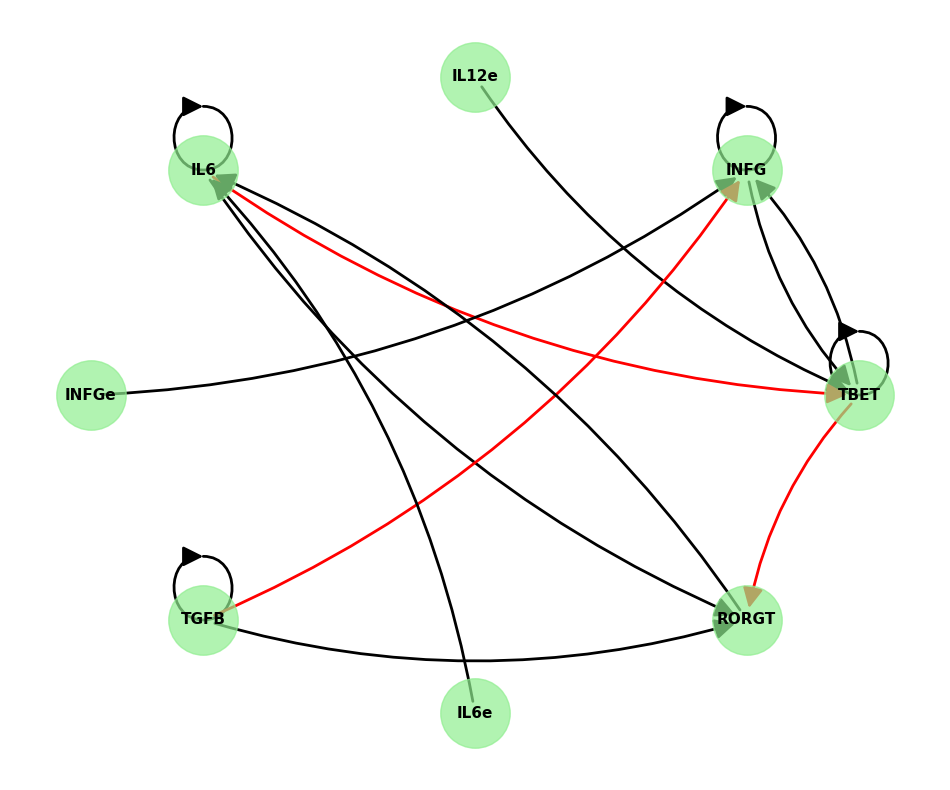

In [59]:
grafo_a_plot(G_Th1vsTh17)

In [60]:
grafo_a_tablainterracciones(G_Th1vsTh17)

,Source,Target,Interaction (Valor)
0,TBET,TBET,1
1,TBET,INFG,1
2,TBET,RORGT,-1
3,INFG,INFG,1
4,INFG,TBET,1
5,IL12e,TBET,1
6,IL6,IL6,1
7,IL6,TBET,-1
8,IL6,RORGT,1
9,INFGe,INFG,1


In [24]:
#Red Th1vsTh2
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/th1vth2.graphml")
G_Th1vsTh2= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th1vsTh2)

,GATA3,IL12e,IL4IL2,IL4e,INFG,INFGe,Tbet
GATA3,1.0,0.0,1.0,0.0,-1.0,0.0,-1.0
IL12e,0.0,0.0,0.0,0.0,0.0,0.0,1.0
IL4IL2,1.0,0.0,1.0,0.0,0.0,0.0,-1.0
IL4e,0.0,0.0,1.0,0.0,0.0,0.0,0.0
INFG,-1.0,0.0,0.0,0.0,1.0,0.0,1.0
INFGe,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Tbet,-1.0,0.0,-1.0,0.0,1.0,0.0,1.0


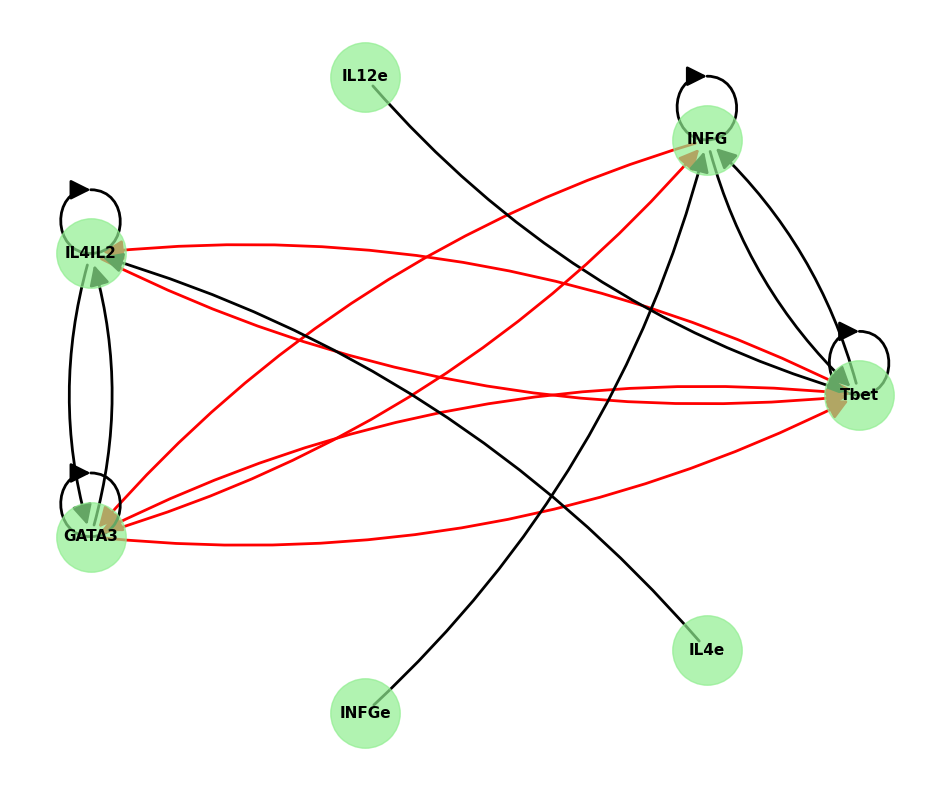

In [25]:
grafo_a_plot(G_Th1vsTh2)

In [26]:
grafo_a_tablainterracciones(G_Th1vsTh2)

,Source,Target,Interaction (Valor)
0,Tbet,Tbet,1
1,Tbet,INFG,1
2,Tbet,GATA3,-1
3,Tbet,IL4IL2,-1
4,INFG,Tbet,1
5,INFG,INFG,1
6,INFG,GATA3,-1
7,IL12e,Tbet,1
8,IL4IL2,IL4IL2,1
9,IL4IL2,GATA3,1


In [33]:
#Red Th1vsiTreg
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/Th1vsiTreg.graphml")
G_Th1vsiTreg= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th1vsiTreg)

,FOXP3,IL10,IL10e,IL12e,INFG,INFGe,TBET,TGFB
FOXP3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
IL10,1.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0
IL10e,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
IL12e,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
INFG,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
INFGe,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
TBET,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
TGFB,1.0,1.0,0.0,0.0,-1.0,0.0,0.0,1.0


In [34]:
grafo_a_tablainterracciones(G_Th1vsiTreg)

,Source,Target,Interaction (Valor)
0,TBET,TBET,1
1,TBET,INFG,1
2,INFG,TBET,1
3,INFG,INFG,1
4,INFG,IL10,1
5,IL12e,TBET,1
6,IL10,TBET,-1
7,IL10,FOXP3,1
8,IL10,IL10,1
9,INFGe,INFG,1


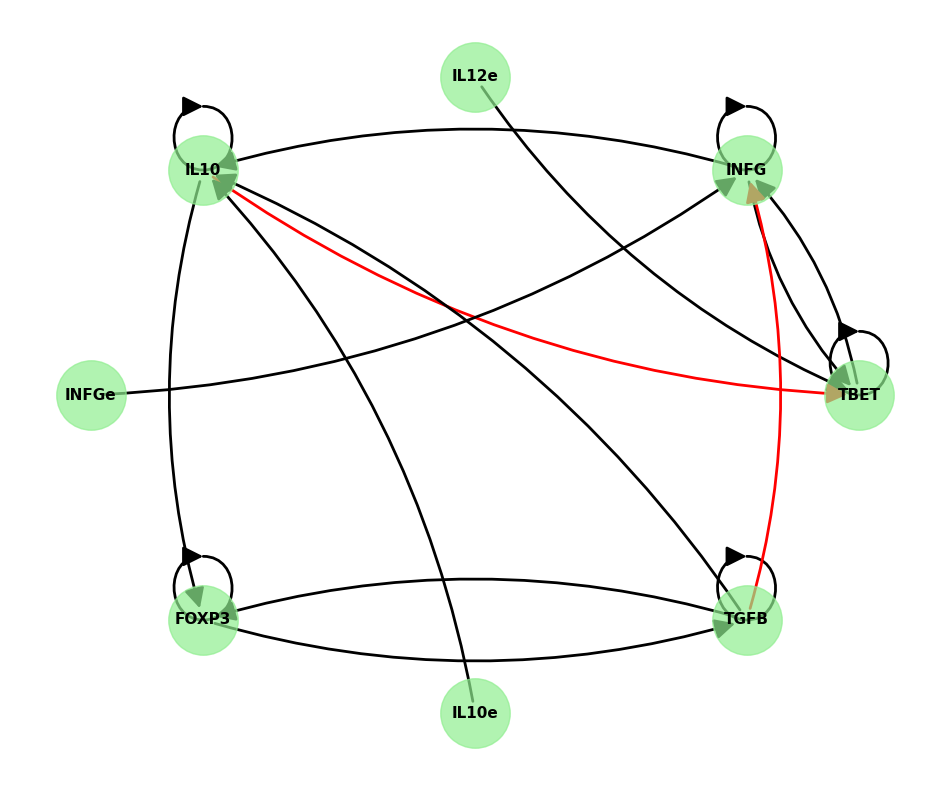

In [35]:
grafo_a_plot(G_Th1vsiTreg)

In [62]:
#Red Th2vsTh17
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/uTh2vsTh17.graphml")
G_Th2vsTh17= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th2vsTh17)

,GATA3,IL4IL2,IL4e,IL6,IL6e,RORGT,TGFB
GATA3,1.0,1.0,0.0,0.0,0.0,-1.0,0.0
IL4IL2,1.0,1.0,0.0,-1.0,0.0,-1.0,0.0
IL4e,0.0,1.0,0.0,0.0,0.0,0.0,0.0
IL6,-1.0,0.0,0.0,1.0,0.0,1.0,-1.0
IL6e,0.0,0.0,0.0,1.0,0.0,0.0,0.0
RORGT,0.0,0.0,0.0,1.0,0.0,0.0,0.0
TGFB,-1.0,0.0,0.0,0.0,0.0,1.0,1.0


In [63]:
grafo_a_tablainterracciones(G_Th2vsTh17)

,Source,Target,Interaction (Valor)
0,GATA3,GATA3,1
1,GATA3,IL4IL2,1
2,GATA3,RORGT,-1
3,TGFB,TGFB,1
4,TGFB,GATA3,-1
5,TGFB,RORGT,1
6,IL4IL2,IL4IL2,1
7,IL4IL2,IL6,-1
8,IL4IL2,GATA3,1
9,IL4IL2,RORGT,-1


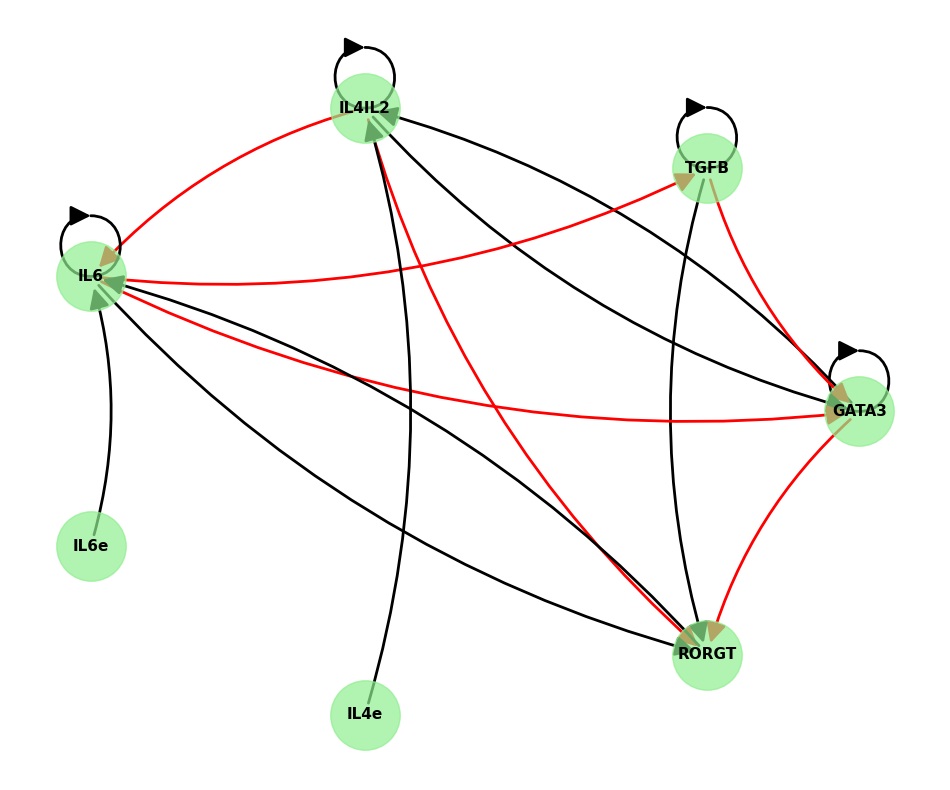

In [64]:
grafo_a_plot(G_Th2vsTh17)

In [54]:
#Red Th2vsiTreg
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/Th2vsiTreg.graphml")
G_Th2vsiTreg= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th2vsiTreg)

,FOXP3,GATA3,IL10,IL10e,IL4IL2,IL4eIL2e,TGFB
FOXP3,1.0,0.0,0.0,0.0,-1.0,0.0,1.0
GATA3,0.0,1.0,1.0,0.0,1.0,0.0,0.0
IL10,1.0,0.0,1.0,0.0,0.0,0.0,0.0
IL10e,0.0,0.0,1.0,0.0,0.0,0.0,0.0
IL4IL2,1.0,1.0,0.0,0.0,1.0,0.0,0.0
IL4eIL2e,0.0,0.0,0.0,0.0,1.0,0.0,0.0
TGFB,1.0,-1.0,1.0,0.0,0.0,0.0,1.0


In [55]:
grafo_a_tablainterracciones(G_Th2vsiTreg)

,Source,Target,Interaction (Valor)
0,GATA3,GATA3,1
1,GATA3,IL10,1
2,GATA3,IL4IL2,1
3,FOXP3,FOXP3,1
4,FOXP3,TGFB,1
5,FOXP3,IL4IL2,-1
6,IL4IL2,IL4IL2,1
7,IL4IL2,FOXP3,1
8,IL4IL2,GATA3,1
9,IL10,FOXP3,1


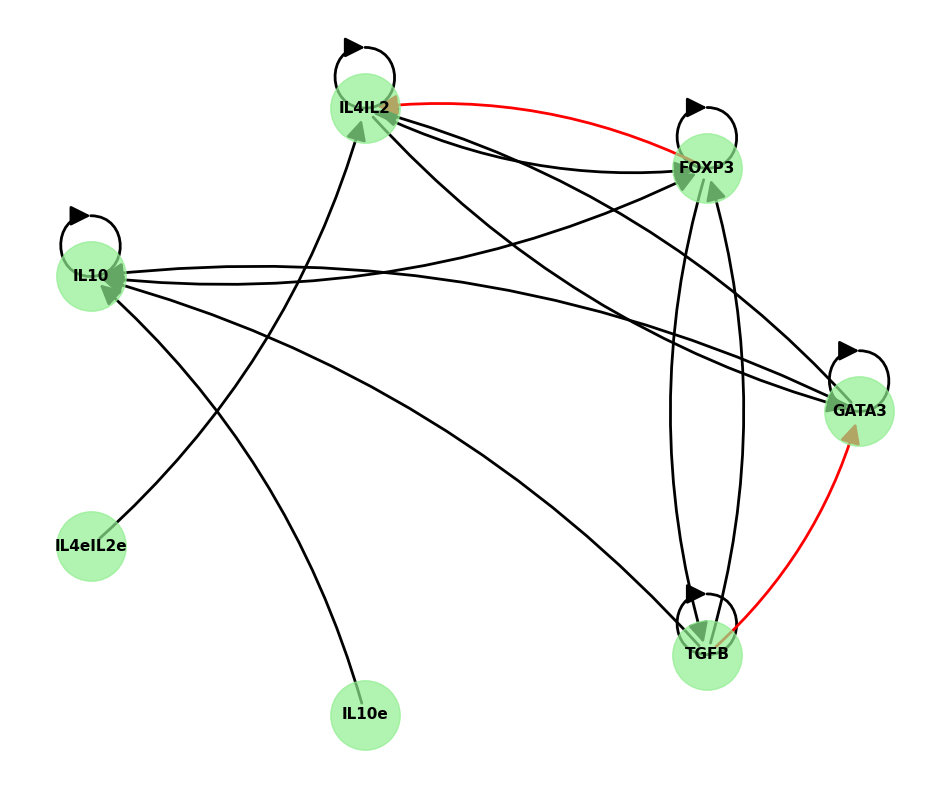

In [56]:
grafo_a_plot(G_Th2vsiTreg)

In [66]:
#Red Th17vsiTreg
G_raw = nx.read_graphml("/Users/isabelrivv/Desktop/Lab-Mariana/Redes/Th17vsiTreg.graphml")
G_Th17vsiTreg= nx.DiGraph(G_raw)

grafo_a_matrizadyacencia(G_Th17vsiTreg)

,FOXP3,IL10,IL10e,IL6,IL6e,RORGT,TGFB
FOXP3,1.0,0.0,0.0,0.0,0.0,-1.0,1.0
IL10,1.0,1.0,0.0,0.0,0.0,0.0,0.0
IL10e,0.0,1.0,0.0,0.0,0.0,0.0,0.0
IL6,-1.0,1.0,0.0,1.0,0.0,1.0,-1.0
IL6e,0.0,0.0,0.0,1.0,0.0,0.0,0.0
RORGT,-1.0,0.0,0.0,1.0,0.0,0.0,0.0
TGFB,1.0,1.0,0.0,0.0,0.0,1.0,1.0


In [67]:
grafo_a_tablainterracciones(G_Th17vsiTreg)

,Source,Target,Interaction (Valor)
0,FOXP3,FOXP3,1
1,FOXP3,TGFB,1
2,FOXP3,RORGT,-1
3,IL6,IL6,1
4,IL6,IL10,1
5,IL6,FOXP3,-1
6,IL6,TGFB,-1
7,IL6,RORGT,1
8,TGFB,TGFB,1
9,TGFB,IL10,1


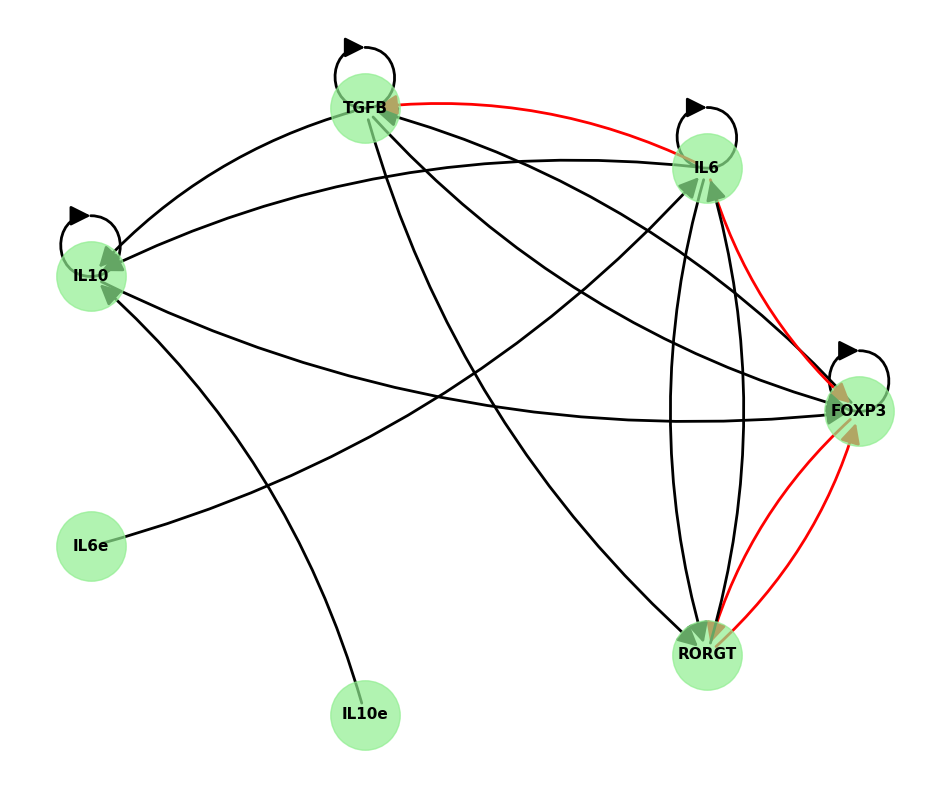

In [68]:
grafo_a_plot(G_Th17vsiTreg)